# Hertz-Kontakt in 3D bei endlichen Deformationen

Zwei elastische Kugelhälften werden verschiebungsgesteuert zusammengedrückt.
Modelliert wird jeweils das Viertel mit $x,y\geq0$: $u_x=0$ auf `X_PLANE`,
$u_y=0$ auf `Y_PLANE`, $u_z=0$ auf `Z_PLANE` und **$u_z=-U$ auf `U_PLANE`**.
Die tangentialen Verschiebungen auf den beiden horizontalen Ebenen sind frei.
Es gibt genau einen Lastfall mit `U = 0.01 mm`; Newton- und Kontaktiterationen
sind keine zusätzlichen Lastschritte.

Verwendet werden lineare Tetraeder (T4), kompressibles Neo-Hooke-Material und
**drei Gaußpunkte je Slave-Dreiecksfläche**. Der Kontakt ist die 3D-Erweiterung
des flächenbezogenen Penalty-Potentials aus Fischer/Wriggers, Gl. (13), (15),
(21), entsprechend `contact_finite_strain`. Die Integration erfolgt punktweise
auf den Slave-Flächen, ohne zusätzliche Mortar-Multiplikatoren oder Segmentierung.
Projektion, Normalen und Flächenmaß werden in der **aktuellen Konfiguration**
berechnet und konsistent differenziert. Kanten und Eckpunkte des diskreten
Masters sind Teil der Suche.

Der Hertz-Vergleich verwendet ausschließlich die berechnete Auflagerreaktion:
$F=4R_{Z,\mathrm{Viertel}}$. Hertz beschreibt den Grenzfall kleiner
Kontaktzonen und kleiner elastischer Verzerrungen; große Deformationen werden
im FEM-Modell berücksichtigt, sind aber außerhalb der Hertz-Annahmen.
Einheiten: mm, N, MPa. Die explizite Kontaktassemblierung ist für **einen MPI-Rang**
implementiert (DOLFINx 0.11, wie die anderen Notebooks).

Quellen: [Fischer & Wriggers (2005)](https://doi.org/10.1007/s00466-005-0660-y),
auch als [lokale PDF](../Frictionless%202D%20Contact%20formula%20-%20Peter%20Wriggers.pdf);
[MIT, Hertzian contact, S. 8](https://ocw.mit.edu/courses/2-002-mechanics-and-materials-ii-spring-2004/ada113f8904250a71dee71f0fdd8c20b_lab_1.pdf).

In [1]:
from pathlib import Path
import heapq
import json

import gmsh
import numpy as np
import ufl
import dolfinx
import dolfinx.fem.petsc
from dolfinx.io import gmsh as gmshio
from mpi4py import MPI
from petsc4py import PETSc
from matplotlib import pyplot as plt

comm = MPI.COMM_WORLD
if comm.size != 1:
    raise RuntimeError("Die manuelle Kontaktassemblierung benötigt genau einen MPI-Rang.")
if np.issubdtype(PETSc.ScalarType, np.complexfloating):
    raise RuntimeError("Dieses Notebook benötigt einen reellen PETSc/DOLFINx-Build.")

R1, R2 = 12.0, 15.0
E1, E2 = 2.1e5, 1.0e5
nu1, nu2 = 0.30, 0.25
U = 0.01                       # einzige Last: u_z = -U auf U_PLANE [mm]
assert U > 0 and min(R1, R2, E1, E2) > 0
assert all(-1.0 < nu < 0.5 for nu in (nu1, nu2))

SLAVE, MASTER = 1, 2
X_PLANE, Y_PLANE, Z_PLANE, U_PLANE = 3, 4, 5, 6
BODY_1, BODY_2 = 7, 8
gdim, fdim = 3, 2
symmetry_factor = 4.0
element = ("Lagrange", 1, (gdim,))

R_ast = 1.0 / (1.0 / R1 + 1.0 / R2)
E_ast = 1.0 / ((1.0 - nu1**2) / E1 + (1.0 - nu2**2) / E2)
a_mesh = np.sqrt(R_ast * U)     # nur Netzskala; keine Kraftkalibrierung!
size_min = a_mesh / 12.0
size_max = R_ast / 3.0
dist_min, dist_max = 1.5 * a_mesh, 16.0 * a_mesh

# Baryzentrische Koordinaten; Referenzdreieck hat Fläche 1/2.
gauss_N = np.array([[2/3, 1/6, 1/6], [1/6, 2/3, 1/6], [1/6, 1/6, 2/3]])
gauss_w = np.full(3, 1.0 / 6.0)
num_gauss = 3
penalty_factor = 30.0
penalty_eps = penalty_factor * E_ast / size_min  # N/mm^3, konstante Penalty

max_newton, max_contact_iter, max_backtracks = 35, 40, 25
atol, rtol = 1.0e-8, 1.0e-9     # freie Kraftresiduen [N]
detF_floor = 1.0e-8
results = Path("results_contact_hertz_3d")
results.mkdir(exist_ok=True)
print(f"DOLFINx {dolfinx.__version__}; h_min={size_min:.4f} mm; "
      f"Penalty={penalty_eps:.4e} N/mm³")

DOLFINx 0.11.0.post0; h_min=0.0215 mm; Penalty=1.0171e+08 N/mm³


In [2]:
# Zwei getrennte Volumina: keine Verschmelzung der anfänglich berührenden Spitzen.
gmsh.initialize()
try:
    gmsh.option.setNumber("General.Terminal", 0)
    gmsh.option.setNumber("General.NumThreads", 1)
    gmsh.model.add("hertz_3d")
    occ = gmsh.model.occ
    upper = occ.addSphere(0, 0, R1, R1,
                          angle1=-np.pi/2, angle2=0, angle3=np.pi/2)
    lower = occ.addSphere(0, 0, -R2, R2,
                          angle1=0, angle2=np.pi/2, angle3=np.pi/2)
    occ.synchronize()

    groups = {tag: [] for tag in (SLAVE, MASTER, X_PLANE, Y_PLANE, Z_PLANE, U_PLANE)}
    # Klassifikation über Geometrie, unabhängig von OCC-Entitätsnummern.
    geo_tol = 1e-8 * max(R1, R2)
    for volume, curved_tag, cap_tag, cap_z in (
        (upper, SLAVE, U_PLANE, R1), (lower, MASTER, Z_PLANE, -R2)
    ):
        for _, surface in gmsh.model.getBoundary([(3, volume)], oriented=False):
            center = np.array(occ.getCenterOfMass(2, surface))
            if gmsh.model.getType(2, surface) == "Sphere":
                tag = curved_tag
            elif abs(center[0]) < geo_tol:
                tag = X_PLANE
            elif abs(center[1]) < geo_tol:
                tag = Y_PLANE
            elif abs(center[2] - cap_z) < geo_tol:
                tag = cap_tag
            else:
                raise RuntimeError(f"Nicht erkannte Randfläche {surface}: {center}")
            groups[tag].append(surface)
    names = {SLAVE: "SLAVE", MASTER: "MASTER", X_PLANE: "X_PLANE",
             Y_PLANE: "Y_PLANE", Z_PLANE: "Z_PLANE", U_PLANE: "U_PLANE"}
    for tag, entities in groups.items():
        assert entities, names[tag]
        gmsh.model.addPhysicalGroup(2, entities, tag, names[tag])
    gmsh.model.addPhysicalGroup(3, [upper], BODY_1, "BODY_1")
    gmsh.model.addPhysicalGroup(3, [lower], BODY_2, "BODY_2")

    tips = [tag for _, tag in gmsh.model.getEntities(0)
            if np.linalg.norm(gmsh.model.getValue(0, tag, [])) < geo_tol]
    assert len(tips) == 2
    distance = gmsh.model.mesh.field.add("Distance")
    gmsh.model.mesh.field.setNumbers(distance, "PointsList", tips)
    threshold = gmsh.model.mesh.field.add("Threshold")
    for name, value in (("InField", distance), ("SizeMin", size_min),
                        ("SizeMax", size_max), ("DistMin", dist_min), ("DistMax", dist_max)):
        gmsh.model.mesh.field.setNumber(threshold, name, value)
    gmsh.model.mesh.field.setAsBackgroundMesh(threshold)
    for name in ("MeshSizeExtendFromBoundary", "MeshSizeFromPoints", "MeshSizeFromCurvature"):
        gmsh.option.setNumber("Mesh." + name, 0)
    gmsh.option.setNumber("Mesh.ElementOrder", 1)
    gmsh.option.setNumber("Mesh.Algorithm3D", 1)
    gmsh.model.mesh.generate(3)
    mesh_data = gmshio.model_to_mesh(gmsh.model, comm, 0, gdim=3)
finally:
    gmsh.finalize()

domain, cell_tags, facet_tags = mesh_data.mesh, mesh_data.cell_tags, mesh_data.facet_tags
assert domain.topology.cell_type == dolfinx.mesh.CellType.tetrahedron
tdim = domain.topology.dim
for d0, d1 in ((tdim, 0), (0, tdim), (fdim, 0), (fdim, tdim)):
    domain.topology.create_connectivity(d0, d1)
facets2vertices = domain.topology.connectivity(fdim, 0)
facets2cells = domain.topology.connectivity(fdim, tdim)
cells2vertices = domain.topology.connectivity(tdim, 0)
slave_facets, master_facets = facet_tags.find(SLAVE), facet_tags.find(MASTER)
cell_indices = np.arange(domain.topology.index_map(tdim).size_local, dtype=np.int32)
print(f"{len(cell_indices)} T4; {len(slave_facets)} Slave- und "
      f"{len(master_facets)} Master-Dreiecke")

36605 T4; 969 Slave- und 1017 Master-Dreiecke


In [3]:
V = dolfinx.fem.functionspace(domain, element)
uh = dolfinx.fem.Function(V, name="u")
du = dolfinx.fem.Function(V)
v, du_trial = ufl.TestFunction(V), ufl.TrialFunction(V)
assert V.dofmap.index_map_bs == 3 and V.dofmap.bs == 3
X = V.tabulate_dof_coordinates().copy()  # Positionen in Verschiebungsblock-Reihenfolge
x_current = X.copy()

# Topologie-, Geometrie- und Verschiebungsindizes sind nicht austauschbar.
# Lokale Zuordnung im Tetraeder vermeidet auch Verwechslung der beiden Spitzen.
nvertices = domain.topology.index_map(0).size_local
vertex_geometry = dolfinx.mesh.entities_to_geometry(
    domain, 0, np.arange(nvertices, dtype=np.int32)
).ravel()
vertex_block = np.full(nvertices, -1, dtype=np.int32)
cell_blocks = np.empty((len(cell_indices), 4), dtype=np.int32)
for cell in cell_indices:
    vertices = cells2vertices.links(cell)
    blocks = V.dofmap.cell_dofs(cell)
    assert len(blocks) == 4
    coordinates = domain.geometry.x[vertex_geometry[vertices]]
    distance2 = np.sum((coordinates[:, None, :] - X[blocks][None, :, :])**2, axis=2)
    local = np.argmin(distance2, axis=1)
    assert len(np.unique(local)) == 4 and np.max(distance2[np.arange(4), local]) < 1e-22
    mapped = blocks[local]
    assert np.all((vertex_block[vertices] < 0) | (vertex_block[vertices] == mapped))
    vertex_block[vertices] = mapped
    cell_blocks[cell] = mapped
assert np.all(vertex_block >= 0)


def boundary_triangles(facets):
    triangles, adjacent = [], []
    for facet in facets:
        nodes = vertex_block[facets2vertices.links(facet)].copy()
        cells = facets2cells.links(facet)
        assert len(nodes) == 3 and len(cells) == 1
        cell = int(cells[0])
        a, b, c = X[nodes]
        # Nach außen orientieren; Orientierung bleibt für det(F)>0 erhalten.
        if np.dot(np.cross(b - a, c - a), X[cell_blocks[cell]].mean(axis=0) - a) > 0:
            nodes[[1, 2]] = nodes[[2, 1]]
        triangles.append(nodes)
        adjacent.append(cell)
    return np.asarray(triangles, dtype=np.int32), np.asarray(adjacent, dtype=np.int32)


slave_nodes, slave_cells = boundary_triangles(slave_facets)
master_nodes, master_cells = boundary_triangles(master_facets)

U_value = dolfinx.fem.Constant(domain, PETSc.ScalarType(-U))


def component_bc(tag, component, value):
    dofs = dolfinx.fem.locate_dofs_topological(V.sub(component), fdim, facet_tags.find(tag))
    return dolfinx.fem.dirichletbc(value, dofs, V.sub(component)), dofs


bc_x, _ = component_bc(X_PLANE, 0, PETSc.ScalarType(0))
bc_y, _ = component_bc(Y_PLANE, 1, PETSc.ScalarType(0))
bc_z, z_dofs = component_bc(Z_PLANE, 2, PETSc.ScalarType(0))
bc_u, u_dofs = component_bc(U_PLANE, 2, U_value)
bcs = [bc_x, bc_y, bc_z, bc_u]
bc_dofs = np.unique(np.concatenate([bc.dof_indices()[0] for bc in bcs])).astype(PETSc.IntType)
free_dofs = np.setdiff1d(np.arange(len(uh.x.array)), bc_dofs)


def neo_hookean_energy(F_def, E, nu):
    mu = E / (2 * (1 + nu))
    kappa = E / (3 * (1 - 2 * nu))
    J_def = ufl.det(F_def)
    I1 = ufl.inner(F_def, F_def)
    # Wie contact_finite_strain: isochorer Anteil + kompressibler Volumenanteil.
    return 0.5 * mu * (J_def**(-2/3) * I1 - 3) + 0.5 * kappa * (J_def - 1)**2


dx = ufl.Measure("dx", domain=domain, subdomain_data=cell_tags,
                 metadata={"quadrature_degree": 2})
ds = ufl.Measure("ds", domain=domain, subdomain_data=facet_tags)
F_def = ufl.variable(ufl.Identity(3) + ufl.grad(uh))
psi1, psi2 = neo_hookean_energy(F_def, E1, nu1), neo_hookean_energy(F_def, E2, nu2)
Pi_bulk = psi1 * dx(BODY_1) + psi2 * dx(BODY_2)
R_bulk = ufl.derivative(Pi_bulk, uh, v)
K_bulk = ufl.derivative(R_bulk, uh, du_trial)
R_form, K_form = dolfinx.fem.form(R_bulk), dolfinx.fem.form(K_bulk)
P1, P2 = ufl.diff(psi1, F_def), ufl.diff(psi2, F_def)
sigma1 = P1 * F_def.T / ufl.det(F_def)  # Cauchy-Spannung in aktueller Konfiguration
sigma2 = P2 * F_def.T / ufl.det(F_def)
detF_expression = dolfinx.fem.Expression(ufl.det(F_def), np.array([[0.25, 0.25, 0.25]]))


def min_detF():
    # Für affine T4 ist F innerhalb jeder Zelle konstant.
    return float(np.min(detF_expression.eval(domain, cell_indices)))


def impose_bcs():
    for bc in bcs:
        bc.set(uh.x.array)


print(f"{len(uh.x.array)} Freiheitsgrade, davon {len(free_dofs)} frei")

22218 Freiheitsgrade, davon 20151 frei


## Kontaktpotential und konsistente Tangente

Für einen Slave-Gaußpunkt mit festen baryzentrischen Koordinaten $N_s$ sei
$\mathbf r=\mathbf x_s-\mathbf x_m(\boldsymbol\xi)$ der Vektor zum nächsten
Punkt des aktuellen Master-Dreiecks. Im Flächeninneren ist
$g_N=\mathbf r\cdot\mathbf n_m$. Bei Kanten-/Eckpunktprojektion verwenden wir,
wie bei den Endpunkten im 2D-Notebook, den vorzeichenbehafteten Abstand
$g_N=\mathrm{sign}(\mathbf r\cdot\mathbf n_m)\|\mathbf r\|$.
Das ist eine stückweise glatte Erweiterung auf die diskrete Oberfläche;
an Feature-Wechseln existiert keine eindeutige klassische zweite Ableitung.

Auf einem aktiven Zweig ($g_N\leq0$) setzen wir
$\phi=\tfrac12\|\mathbf r\|^2$ und
$j_s=\|(\mathbf x_{s2}-\mathbf x_{s1})\times(\mathbf x_{s3}-\mathbf x_{s1})\|$.
Damit gilt pro Gaußpunkt mit $w=1/6$:

$$\Pi_c=w\epsilon_N j_s\phi,\qquad
\mathbf R_c=w\epsilon_N(j_s\mathbf D+\phi\mathbf L),$$
$$\mathbf K_c=w\epsilon_N\left[
j_s\mathbf H_\phi+\mathbf D\otimes\mathbf L+
\mathbf L\otimes\mathbf D+\phi\mathbf H_j\right],$$

wobei $\mathbf D=\partial\phi/\partial\mathbf q$,
$\mathbf L=\partial j_s/\partial\mathbf q$ und die beiden $\mathbf H$ die
zugehörigen Hesse-Matrizen bezüglich der 18 lokalen Freiheitsgrade sind.
**Alle Flächenvariationen bleiben erhalten**, einschließlich $\mathbf H_j$.

Die Projektionskoordinaten werden analytisch eliminiert. Mit
$\mathbf H=[N_s\otimes\mathbf I,-N_m\otimes\mathbf I]$,
Master-Tangenten $\mathbf A=[\mathbf a_1,\mathbf a_2]$ und
$\mathbf B_\alpha=\partial\mathbf a_\alpha/\partial\mathbf q$ folgt aus der
Stationarität der Abstandsfunktion:

$$\mathbf D=\mathbf H^T\mathbf r,\qquad
\mathbf H_\phi=\mathbf H^T\mathbf H-
\mathbf C^T(\mathbf A^T\mathbf A)^{-1}\mathbf C,\qquad
\mathbf C_\alpha=\mathbf a_\alpha^T\mathbf H+\mathbf r^T\mathbf B_\alpha.$$

Im Flächeninneren werden zwei Koordinaten eliminiert, auf einer Kante eine,
an einem Eckpunkt keine. Das Schur-Komplement enthält die Ableitungen der
gleitenden Projektion und der Normalen; es werden keine Projektionskoordinaten
in der Tangente eingefroren. Dies ist eine analytische Ableitung, keine
numerische Differentiation im Solver. Zentrale Differenzen dienen unten nur
der unabhängigen Prüfung.

In [4]:
def closest_on_triangles(point, triangles):
    """Exaktes Minimum auf jedem geschlossenen Dreieck: Fläche oder drei Kanten."""
    a = triangles[:, 0]
    e1, e2 = triangles[:, 1] - a, triangles[:, 2] - a
    d = point - a
    g11 = np.einsum("ij,ij->i", e1, e1)
    g12 = np.einsum("ij,ij->i", e1, e2)
    g22 = np.einsum("ij,ij->i", e2, e2)
    b1 = np.einsum("ij,ij->i", e1, d)
    b2 = np.einsum("ij,ij->i", e2, d)
    determinant = g11 * g22 - g12**2
    if np.any(determinant <= 0):
        raise RuntimeError("Degeneriertes Master-Dreieck")
    xi = (g22 * b1 - g12 * b2) / determinant
    eta = (g11 * b2 - g12 * b1) / determinant
    N = np.stack((1 - xi - eta, xi, eta), axis=1)
    projected = np.einsum("ni,nij->nj", N, triangles)
    distance2 = np.sum((point - projected)**2, axis=1)
    distance2[np.any(N < 0.0, axis=1)] = np.inf
    for i, j in ((0, 1), (1, 2), (2, 0)):
        edge = triangles[:, j] - triangles[:, i]
        t = np.clip(np.einsum("ij,ij->i", point - triangles[:, i], edge)
                    / np.einsum("ij,ij->i", edge, edge), 0.0, 1.0)
        edge_point = triangles[:, i] + t[:, None] * edge
        edge_dist2 = np.sum((point - edge_point)**2, axis=1)
        better = edge_dist2 < distance2
        N[better] = 0.0
        N[better, i], N[better, j] = 1 - t[better], t[better]
        distance2[better] = edge_dist2[better]
    return N, distance2


class TriangleSearch:
    """AABB-Hierarchie mit exakter Distanzschranke, ohne Suchradius-Abschneiden.

    Die Baumtopologie ist fest; alle Boxen werden für jede neue Geometrie
    aktualisiert. Somit sind auch große Verschiebungen/Gleitungen zulässig.
    """

    def __init__(self, triangles, leaf_size=8):
        self.nodes = []
        centers = triangles.mean(axis=1)

        def build(ids):
            index = len(self.nodes)
            self.nodes.append(None)
            if len(ids) <= leaf_size:
                self.nodes[index] = (ids, -1, -1)
            else:
                axis = np.argmax(np.ptp(centers[ids], axis=0))
                order = ids[np.argsort(centers[ids, axis])]
                middle = len(order) // 2
                left, right = build(order[:middle]), build(order[middle:])
                self.nodes[index] = (None, left, right)
            return index

        build(np.arange(len(triangles)))
        self.lo = np.empty((len(self.nodes), 3))
        self.hi = np.empty_like(self.lo)
        self.update(triangles)

    def update(self, triangles):
        self.triangles = triangles
        for k in range(len(self.nodes) - 1, -1, -1):
            ids, left, right = self.nodes[k]
            if ids is not None:
                self.lo[k] = triangles[ids].min(axis=(0, 1))
                self.hi[k] = triangles[ids].max(axis=(0, 1))
            else:
                self.lo[k] = np.minimum(self.lo[left], self.lo[right])
                self.hi[k] = np.maximum(self.hi[left], self.hi[right])

    def closest(self, point):
        def bound(k):
            d = np.maximum(np.maximum(self.lo[k] - point, point - self.hi[k]), 0.0)
            return float(d @ d)

        best_distance2, best_triangle, best_N = np.inf, None, None
        queue = [(bound(0), 0)]
        while queue:
            lower_bound, k = heapq.heappop(queue)
            if lower_bound > best_distance2 * (1 + 1e-13) + 1e-28:
                continue
            ids, left, right = self.nodes[k]
            if ids is None:
                heapq.heappush(queue, (bound(left), left))
                heapq.heappush(queue, (bound(right), right))
            else:
                N, distance2 = closest_on_triangles(point, self.triangles[ids])
                i = int(np.argmin(distance2))
                if distance2[i] < best_distance2:
                    best_distance2 = float(distance2[i])
                    best_triangle, best_N = int(ids[i]), N[i].copy()
        if best_triangle is None:
            raise RuntimeError("Keine Master-Projektion gefunden")
        return best_triangle, best_N


master_search = TriangleSearch(X[master_nodes])


def update_geometry():
    uh.x.scatter_forward()
    x_current[:] = X + uh.x.array.reshape(-1, 3)
    master_search.update(x_current[master_nodes])


def contact_projection(slave, igp):
    xs = gauss_N[igp] @ x_current[slave_nodes[slave]]
    master, Nm = master_search.closest(xs)
    triangle = x_current[master_nodes[master]]
    normal = np.cross(triangle[1] - triangle[0], triangle[2] - triangle[0])
    normal /= np.linalg.norm(normal)
    r = xs - Nm @ triangle
    sign = -1.0 if r @ normal <= 0.0 else 1.0
    gap = sign * np.linalg.norm(r)
    return master, Nm, gap


def active_points():
    return tuple((s, q) for s in range(len(slave_nodes)) for q in range(num_gauss)
                 if contact_projection(s, q)[2] <= 0.0)

In [5]:
I3 = np.eye(3)


def skew(a):
    return np.array([[0, -a[2], a[1]], [a[2], 0, -a[0]], [-a[1], a[0], 0]])


def edge_operator(i, j):
    B = np.zeros((3, 18))
    B[:, 3*i:3*i+3] = -I3
    B[:, 3*j:3*j+3] = I3
    return B


Bs1, Bs2 = edge_operator(0, 1), edge_operator(0, 2)
Bm = {(i, j): edge_operator(3 + i, 3 + j) for i in range(3) for j in range(3) if i != j}


def surface_measure(q, tangent=True):
    """j_s = 2 * aktuelle Dreiecksfläche, Gradient und exakte Hesse-Matrix."""
    e1, e2 = q[1] - q[0], q[2] - q[0]
    cross = np.cross(e1, e2)
    jac = np.linalg.norm(cross)
    if jac <= 0:
        raise RuntimeError("Degeneriertes Slave-Dreieck")
    normal = cross / jac
    Q = -skew(e2) @ Bs1 + skew(e1) @ Bs2
    L = Q.T @ normal
    Hj = None
    if tangent:
        M = -Bs1.T @ skew(normal) @ Bs2
        Hj = Q.T @ ((I3 - np.outer(normal, normal)) / jac) @ Q + M + M.T
    return jac, L, Hj


def contact_kernel(q, Ns, Nm, weight, tangent=True):
    """Gradient/Hesse-Matrix des aktiven 18-DOF-Potentials.

    Nm muss die NEU berechnete nächste Projektion sein. Die Ableitungen
    berücksichtigen ihre Abhängigkeit von allen lokalen Koordinaten.
    Kanten-/Eckzweige werden durch die positiven Baryzentrikkoordinaten bestimmt.
    """
    r = Ns @ q[:3] - Nm @ q[3:]
    phi = 0.5 * (r @ r)
    H = np.kron(np.r_[Ns, -Nm][None, :], I3)
    D = H.T @ r
    jac, L, Hj = surface_measure(q, tangent)
    scale = weight * penalty_eps
    Rc = scale * (jac * D + phi * L)
    Kc = None
    if tangent:
        Hphi = H.T @ H
        feature = np.flatnonzero(Nm > 0.0)
        if len(feature) > 1:
            origin = feature[0]
            tangents = np.column_stack([q[3 + j] - q[3 + origin] for j in feature[1:]])
            C = np.stack([tangents[:, k] @ H + r @ Bm[origin, j]
                          for k, j in enumerate(feature[1:])])
            Hphi -= C.T @ np.linalg.solve(tangents.T @ tangents, C)
        Kc = scale * (jac * Hphi + np.outer(D, L) + np.outer(L, D) + phi * Hj)
    return scale * jac * phi, Rc, Kc

In [6]:
# Unabhängige lokale Prüfungen: alle 18 Richtungen, endliche Rotation/Verzerrung,
# Flächen-, Kanten- und Eckprojektion. FD wird ausschließlich hier verwendet.
def check_contact_linearization():
    rng = np.random.default_rng(12)
    Ns = gauss_N[0]
    master = np.array([[0., 0., 0.], [1.2, 0., 0.], [0.1, 1.1, 0.]])
    offsets = np.array([[-.2, -.1, .02], [.3, -.07, -.04], [-.05, .31, .08]])
    offsets -= Ns @ offsets
    rotation, _ = np.linalg.qr(rng.normal(size=(3, 3)))
    rotation[:, 0] *= np.linalg.det(rotation)
    stretch = np.diag([1.3, .8, 1.1])
    translation = np.array([.4, -.7, .9])
    errors = []
    for name, point, nfeature in (
        ("Fläche", [.35, .3, -.12], 3),
        ("Kante", [.5, -.2, -.15], 2),
        ("Ecke", [-.25, -.2, -.1], 1),
    ):
        q = np.vstack((np.asarray(point) + offsets, master)) @ stretch @ rotation.T + translation

        def evaluate(z):
            weights, _ = closest_on_triangles(Ns @ z[:3], z[None, 3:])
            return contact_kernel(z, Ns, weights[0], gauss_w[0])

        weights, _ = closest_on_triangles(Ns @ q[:3], q[None, 3:])
        assert np.count_nonzero(weights[0] > 0) == nfeature
        energy, force, stiffness = evaluate(q)
        h = 1e-6
        gradient_fd, tangent_fd = np.empty(18), np.empty((18, 18))
        for j in range(18):
            delta = np.zeros(18)
            delta[j] = h
            Ep, Rp, _ = evaluate(q + delta.reshape(6, 3))
            Em, Rm, _ = evaluate(q - delta.reshape(6, 3))
            gradient_fd[j] = (Ep - Em) / (2 * h)
            tangent_fd[:, j] = (Rp - Rm) / (2 * h)
        err_r = np.linalg.norm(force - gradient_fd) / np.linalg.norm(force)
        err_k = np.linalg.norm(stiffness - tangent_fd) / np.linalg.norm(stiffness)
        err_sym = np.linalg.norm(stiffness - stiffness.T) / np.linalg.norm(stiffness)
        # Objektivität: gemeinsame Translation und endliche Rotation.
        E_rot, R_rot, K_rot = evaluate(q @ rotation.T + translation)
        transform = np.kron(np.eye(6), rotation)
        assert np.isclose(E_rot, energy, rtol=1e-12)
        np.testing.assert_allclose(R_rot, transform @ force, rtol=1e-11, atol=1e-7)
        np.testing.assert_allclose(K_rot, transform @ stiffness @ transform.T, rtol=1e-10, atol=1e-7)
        assert np.linalg.norm(force.reshape(6, 3).sum(axis=0)) < 1e-12 * np.linalg.norm(force)
        assert max(err_r, err_k) < 2e-7 and err_sym < 1e-13
        errors.append((name, err_r, err_k))
        print(f"{name:6s}: Gradient-FD {err_r:.2e}, Tangenten-FD {err_k:.2e}, Symmetrie {err_sym:.2e}")
    # Die Dreipunktregel integriert alle Polynome bis Grad 2 exakt.
    np.testing.assert_allclose(gauss_w.sum(), .5)
    np.testing.assert_allclose(gauss_w @ gauss_N, np.full(3, 1/6))
    np.testing.assert_allclose(gauss_w @ gauss_N**2, np.full(3, 1/12))
    np.testing.assert_allclose(gauss_w @ (gauss_N[:, 0] * gauss_N[:, 1]), 1/24)
    # Suchbaum gegen vollständige Suche, einschließlich einer bewegten Oberfläche.
    test_triangles = rng.normal(size=(35, 3, 3))
    tree = TriangleSearch(test_triangles)
    for triangles in (test_triangles, test_triangles @ stretch @ rotation.T + translation):
        tree.update(triangles)
        for point in rng.normal(size=(12, 3)):
            k, N = tree.closest(point)
            _, distance2 = closest_on_triangles(point, triangles)
            np.testing.assert_allclose(np.sum((point - N @ triangles[k])**2), distance2.min(), atol=1e-13)
    return errors


local_tangent_checks = check_contact_linearization()

Fläche: Gradient-FD 1.39e-10, Tangenten-FD 2.57e-10, Symmetrie 1.29e-16
Kante : Gradient-FD 7.53e-11, Tangenten-FD 1.22e-10, Symmetrie 7.19e-17
Ecke  : Gradient-FD 9.09e-11, Tangenten-FD 8.72e-11, Symmetrie 4.85e-17


## Nichtlineare Lösung für einen Lastfall

Die äußere aktive Mengeniteration entspricht dem Vorgehen in Box 2 von
Fischer/Wriggers: innerhalb eines Newton-Laufs bleiben nur die aktiven
Slave-Gaußpunkte fest. Ihre Master-Dreiecke und Projektionskoordinaten werden
bei **jeder** Residuen-/Tangentenauswertung neu gesucht. Danach wird die gesamte
aktive Menge geprüft. Backtracking verwendet das freie Kraftresiduum und
verwirft jeden Versuch mit $\det\mathbf F\leq0$.

Ein glattes anfängliches Verschiebungsfeld erfüllt bereits den Endwert $-U$
auf `U_PLANE` und verteilt die Annäherung nahe der Kontaktspitze auf beide
Körper. Es dient nur als Newton-Startwert; sämtliche freien Freiheitsgrade
werden anschließend aus dem Gleichgewicht berechnet. Dadurch startet der
Solver mit geringer Penetration, auch bei feinen Netzen und größeren `U`.

In [7]:
R_vec = dolfinx.fem.petsc.create_vector(V)
K_mat = dolfinx.fem.petsc.create_matrix(K_form)
K_mat.setOption(PETSc.Mat.Option.NEW_NONZERO_ALLOCATION_ERR, False)
rhs = R_vec.duplicate()
ksp = PETSc.KSP().create(comm)
ksp.setType("preonly")
ksp.getPC().setType("lu")
if PETSc.Sys.hasExternalPackage("mumps"):
    ksp.getPC().setFactorSolverType("mumps")


def assemble_contact(matrix, vector, active):
    energy = 0.0
    for slave, igp in active:
        master, Nm, _ = contact_projection(slave, igp)
        nodes = np.r_[slave_nodes[slave], master_nodes[master]]
        rows = (3 * nodes[:, None] + np.arange(3)).ravel().astype(PETSc.IntType)
        Ec, Rc, Kc = contact_kernel(x_current[nodes], gauss_N[igp], Nm,
                                     gauss_w[igp], tangent=matrix is not None)
        vector.setValues(rows, Rc, addv=PETSc.InsertMode.ADD_VALUES)
        if matrix is not None:
            matrix.setValues(rows, rows, Kc, addv=PETSc.InsertMode.ADD_VALUES)
        energy += Ec
    return energy


def assemble_system(active, tangent=True):
    """R_vec bleibt UNMODIFIZIERT für die Reaktionen; nur K wird eliminiert."""
    with R_vec.localForm() as local:
        local.set(0.0)
    dolfinx.fem.petsc.assemble_vector(R_vec, R_form)
    if tangent:
        K_mat.zeroEntries()
        dolfinx.fem.petsc.assemble_matrix(K_mat, K_form)
    assemble_contact(K_mat if tangent else None, R_vec, active)
    R_vec.assemble()
    if tangent:
        K_mat.assemble()
        K_mat.zeroRowsColumns(bc_dofs, diag=1.0)
    return float(np.linalg.norm(R_vec.array[free_dofs]))


# Nur ein vorgegebener Endwert; keine inkrementelle Lastschleife.
upper_blocks = np.unique(cell_blocks[cell_tags.find(BODY_1)])
lower_blocks = np.unique(cell_blocks[cell_tags.find(BODY_2)])
uh.x.array[:] = 0
# Räumlich abklingender Prädiktor; kein zusätzlicher Lastschritt und keine
# vorgegebene Hertz-Kraft. Die Nachgiebigkeiten teilen nur den Startwert auf.
compliance1, compliance2 = (1 - nu1**2) / E1, (1 - nu2**2) / E2
fraction1 = compliance1 / (compliance1 + compliance2)
fraction2 = 1 - fraction1
scaled_distance = np.linalg.norm(X, axis=1) / a_mesh
# C1-Profil: lokale Parabel bis a_mesh, anschließend exponentielles Abklingen.
# Die Parabel kompensiert näherungsweise den quadratischen Kugelspalt.
decay = np.empty_like(scaled_distance)
inside = scaled_distance <= 1.0
decay[inside] = 1 - 0.5 * scaled_distance[inside]**2
decay[~inside] = 0.5 * np.exp(-2 * (scaled_distance[~inside] - 1))
predictor_fraction = 0.98
u_start = uh.x.array.reshape(-1, 3)
u_start[upper_blocks, 2] = -U + predictor_fraction * fraction1 * U * decay[upper_blocks] * (1 - X[upper_blocks, 2] / R1)
u_start[lower_blocks, 2] = -predictor_fraction * fraction2 * U * decay[lower_blocks] * (1 + X[lower_blocks, 2] / R2)
impose_bcs()
update_geometry()
assert min_detF() > detF_floor
active = active_points()
if not active:
    raise RuntimeError("Kein aktiver Gaußpunkt: Kontaktzone feiner vernetzen oder U erhöhen.")

history = []
initial_norm = assemble_system(active, tangent=False)
force_tolerance = atol + rtol * initial_norm
print(f"Anfang: {len(active)} aktive GP, |R_frei|={initial_norm:.3e} N, "
      f"Toleranz={force_tolerance:.3e} N")
converged = False
for contact_iteration in range(max_contact_iter):
    for iteration in range(max_newton):
        residual_norm = assemble_system(active)
        if not np.isfinite(residual_norm):
            raise RuntimeError("Nichtendliches Kraftresiduum")
        if residual_norm <= force_tolerance:
            break
        R_vec.copy(rhs)
        rhs.scale(-1)
        rhs.setValues(bc_dofs, np.zeros(len(bc_dofs)), addv=PETSc.InsertMode.INSERT_VALUES)
        rhs.assemble()
        ksp.setOperators(K_mat)
        ksp.solve(rhs, du.x.petsc_vec)
        if ksp.getConvergedReason() <= 0 or not np.all(np.isfinite(du.x.array)):
            raise RuntimeError("Lineare Newton-Lösung fehlgeschlagen")
        previous = uh.x.array.copy()
        step_length = 1.0
        for backtrack in range(max_backtracks):
            uh.x.array[:] = previous + step_length * du.x.array
            impose_bcs()
            update_geometry()
            trial_det = min_detF()
            if np.isfinite(trial_det) and trial_det > detF_floor:
                trial_norm = assemble_system(active, tangent=False)
                if np.isfinite(trial_norm) and trial_norm <= (1 - 1e-4 * step_length) * residual_norm:
                    break
            step_length *= 0.5
        else:
            uh.x.array[:] = previous
            update_geometry()
            raise RuntimeError(f"Backtracking fehlgeschlagen: Kontakt {contact_iteration}, "
                               f"Newton {iteration}, |R|={residual_norm:.3e} N")
        history.append((contact_iteration, iteration, trial_norm, step_length, trial_det))
        print(f"Kontakt {contact_iteration:2d}, Newton {iteration:2d}: "
              f"|R_frei|={trial_norm:.3e} N, alpha={step_length:.3f}, min(detF)={trial_det:.6f}")
    else:
        raise RuntimeError("Newton hat die Krafttoleranz nicht erreicht")
    updated_active = active_points()
    print(f"Aktive Menge: {len(active)} -> {len(updated_active)} GP")
    if updated_active == active:
        converged = True
        break
    active = updated_active
if not converged:
    raise RuntimeError("Aktive Kontaktmenge hat sich nicht stabilisiert")

residual_norm = assemble_system(active)
assert residual_norm <= force_tolerance and min_detF() > detF_floor
with dolfinx.io.XDMFFile(comm, results / "displacement.xdmf", "w") as out:
    out.write_mesh(domain)
    out.write_function(uh, 1.0)
print(f"Konvergiert für U={U:g} mm: |R_frei|={residual_norm:.3e} N")

Anfang: 943 aktive GP, |R_frei|=9.999e+01 N, Toleranz=1.100e-07 N


Kontakt  0, Newton  0: |R_frei|=6.559e-01 N, alpha=1.000, min(detF)=0.976904


Kontakt  0, Newton  1: |R_frei|=4.262e-03 N, alpha=1.000, min(detF)=0.976343


Kontakt  0, Newton  2: |R_frei|=9.722e-09 N, alpha=1.000, min(detF)=0.976341


Aktive Menge: 943 -> 890 GP


...

Kontakt  4, Newton  1: |R_frei|=1.817e-09 N, alpha=1.000, min(detF)=0.976400


Aktive Menge: 817 -> 814 GP


Kontakt  5, Newton  0: |R_frei|=6.854e-08 N, alpha=1.000, min(detF)=0.976400


Aktive Menge: 814 -> 814 GP


Konvergiert für U=0.01 mm: |R_frei|=6.854e-08 N


In [8]:
# Globale Richtungsableitung prüft Material + Kontakt + DOF-Zuordnung gemeinsam.
# Die aktive Menge bleibt fest; die Projektionen werden auch in den FD-Versuchen neu gesucht.
def check_global_tangent():
    rng = np.random.default_rng(29)
    direction = np.zeros_like(uh.x.array)
    contact_blocks = np.unique(np.r_[slave_nodes.ravel(), master_nodes.ravel()])
    contact_dofs = (3 * contact_blocks[:, None] + np.arange(3)).ravel()
    direction[contact_dofs] = rng.normal(size=len(contact_dofs))
    direction[bc_dofs] = 0
    direction /= np.linalg.norm(direction)
    saved = uh.x.array.copy()
    assemble_system(active)
    test_vector, product = R_vec.duplicate(), R_vec.duplicate()
    try:
        test_vector.array[:] = direction
        K_mat.mult(test_vector, product)
        exact = product.array[free_dofs].copy()
        errors = []
        for h in (1e-5 * size_min, 5e-6 * size_min):
            residuals = []
            for sign in (1, -1):
                uh.x.array[:] = saved + sign * h * direction
                update_geometry()
                assemble_system(active, tangent=False)
                residuals.append(R_vec.array[free_dofs].copy())
            fd = (residuals[0] - residuals[1]) / (2 * h)
            errors.append(float(np.linalg.norm(fd - exact) / np.linalg.norm(exact)))
        assert max(errors) < 5e-5, f"Globale Tangentenprüfung fehlgeschlagen: {errors}"
    finally:
        uh.x.array[:] = saved
        update_geometry()
        assemble_system(active)
        test_vector.destroy()
        product.destroy()
    print("Globale Tangentenprüfung (relative Fehler):", [f"{e:.2e}" for e in errors])
    return errors


global_tangent_errors = check_global_tangent()

Globale Tangentenprüfung (relative Fehler): ['1.20e-08', '2.71e-08']


## Reaktionskraft und Vergleich mit der Hertz-Lösung

Die Auflagerreaktion wird aus dem **vollständig assemblierten Residuum vor
dem Überschreiben von Dirichlet-Zeilen** bestimmt. Dadurch erfüllt sie die
diskrete globale Kräftebilanz. Die zusätzliche Spannungsintegration verwendet
den ersten Piola-Kirchhoff-Tensor $\mathbf P$ auf der Referenzfläche; eine
Integration von Cauchy-Spannungen auf unverformten Flächen wäre bei großen
Deformationen falsch. Bei T4 ist die Spannungsintegration am Auflager nur eine
approximative Kontrolle, nicht die für Hertz verwendete Reaktion.

$$R_{Z,\mathrm{Viertel}}=\sum_{i\in Z\_PLANE,z}R_i,\quad
F=4R_{Z,\mathrm{Viertel}},\quad
\frac1{R^*}=\frac1{R_1}+\frac1{R_2},\quad
\frac1{E^*}=\frac{1-\nu_1^2}{E_1}+\frac{1-\nu_2^2}{E_2},$$
$$a=\left(\frac{3FR^*}{4E^*}\right)^{1/3},\quad
p_0=\frac{3F}{2\pi a^2},\quad
p_H(r)=p_0\sqrt{\max(0,1-r^2/a^2)}.$$

Gezeigt werden der Penalty-Druck $p_N=-\epsilon_N\min(g_N,0)$ an den drei
Gaußpunkten und, analog zu `contact_hertz`, der aus den FEM-Cauchy-Spannungen
bestimmte Druck $-\mathbf n_s^T\boldsymbol\sigma\mathbf n_s$.
Der Radius $r$ wird in der aktuellen Konfiguration gemessen.
Eine Flächengewichtung liefert radiale Mittelwerte; die einzelnen Punkte
bleiben sichtbar, damit Netz- und Penalty-Effekte erkennbar sind.

In [9]:
assemble_system(active, tangent=False)
reaction_z_quarter = float(np.sum(R_vec.array[z_dofs]))
reaction_u_quarter = float(np.sum(R_vec.array[u_dofs]))
if reaction_z_quarter <= 0:
    raise RuntimeError("Erwartet wird eine positive Druckreaktion an Z_PLANE.")
F = symmetry_factor * reaction_z_quarter   # volle Kugelkraft für Hertz, keine Kalibrierung
a = (3 * F * R_ast / (4 * E_ast))**(1/3)
p0 = 3 * F / (2 * np.pi * a**2)
delta_hertz = a**2 / R_ast
force_balance = abs(reaction_z_quarter + reaction_u_quarter) / reaction_z_quarter
assert force_balance < 1e-6

N_ref = ufl.FacetNormal(domain)
reaction_z_stress = float(dolfinx.fem.assemble_scalar(
    dolfinx.fem.form(ufl.dot(P2, N_ref)[2] * ds(Z_PLANE))))
stress_expression = dolfinx.fem.Expression(sigma1, np.array([[.25, .25, .25]]))
slave_stresses = stress_expression.eval(domain, slave_cells).reshape(-1, 3, 3)

records = []
active_set = set(active)
for slave, nodes in enumerate(slave_nodes):
    triangle = x_current[nodes]
    area_vector = np.cross(triangle[1] - triangle[0], triangle[2] - triangle[0])
    jac = np.linalg.norm(area_vector)
    normal_s = area_vector / jac
    p_stress = -float(normal_s @ slave_stresses[slave] @ normal_s)
    for igp in range(num_gauss):
        master, Nm, gap = contact_projection(slave, igp)
        point = gauss_N[igp] @ triangle
        xm = Nm @ x_current[master_nodes[master]]
        p_contact = -penalty_eps * min(gap, 0.0)
        # Generalisierte Abstandsnormale; bei Flächenprojektion identisch zu n_m.
        if gap < 0:
            normal_contact = (point - xm) / gap
        else:
            tm = x_current[master_nodes[master]]
            normal_contact = np.cross(tm[1] - tm[0], tm[2] - tm[0])
            normal_contact /= np.linalg.norm(normal_contact)
        records.append((point[0], point[1], point[2], np.linalg.norm(point[:2]), gap,
                        p_contact, p_stress, gauss_w[igp] * jac,
                        float((slave, igp) in active_set), normal_contact[2], abs(normal_s[2])))
contact_data = np.asarray(records)
r_gp, gaps = contact_data[:, 3], contact_data[:, 4]
p_gp, p_sigma, area_weights = contact_data[:, 5], contact_data[:, 6], contact_data[:, 7]
is_active = contact_data[:, 8].astype(bool)
projected_area_weights = area_weights * contact_data[:, 10]
contact_area = symmetry_factor * np.sum(projected_area_weights[is_active])
a_fem_area = np.sqrt(contact_area / np.pi)
contact_force_z = symmetry_factor * np.sum(p_gp * area_weights * contact_data[:, 9])
contact_force_balance = abs(contact_force_z - F) / F
assert contact_force_balance < 1e-6
penetration_max = max(0.0, -float(np.min(gaps)))


def hertz_pressure(radius):
    return p0 * np.sqrt(np.maximum(0.0, 1.0 - (np.asarray(radius) / a)**2))


# Flächengewichteter relativer L2-Fehler inkl. Kontaktrand und eventueller Druckwerte außerhalb a.
near = r_gp <= 1.5 * max(a, a_fem_area)
p_hertz_gp = hertz_pressure(r_gp)
pressure_error = np.sqrt(np.sum(area_weights[near] * (p_gp[near] - p_hertz_gp[near])**2)
                         / np.sum(area_weights[near] * p_hertz_gp[near]**2))
sigma_error = np.sqrt(np.sum(area_weights[near] * (p_sigma[near] - p_hertz_gp[near])**2)
                      / np.sum(area_weights[near] * p_hertz_gp[near]**2))
summary = dict(U_mm=U, cells_T4=len(cell_indices), dofs=len(uh.x.array),
               gauss_points_per_face=num_gauss, active_gauss_points=len(active),
               reaction_Z_quarter_N=reaction_z_quarter, reaction_U_quarter_N=reaction_u_quarter,
               F_N=F, reaction_Z_stress_quarter_N=reaction_z_stress,
               force_balance_relative=force_balance, contact_pressure_force_N=contact_force_z,
               contact_force_balance_relative=contact_force_balance,
               a_Hertz_mm=a, a_FEM_area_mm=a_fem_area, p0_Hertz_MPa=p0,
               pmax_penalty_MPa=float(p_gp.max()), delta_Hertz_mm=delta_hertz,
               max_penetration_mm=penetration_max, min_detF=min_detF(),
               residual_N=residual_norm, pressure_L2_relative=float(pressure_error),
               stress_pressure_L2_relative=float(sigma_error), global_tangent_errors=global_tangent_errors)
print(f"R_Z (Viertel) = {reaction_z_quarter:.8f} N; R_U (Viertel) = {reaction_u_quarter:.8f} N")
print(f"F = 4 R_Z = {F:.8f} N; relative Kräftebilanz = {force_balance:.3e}")
print(f"Kontrollintegral 4 ∫ p_N n_z da = {contact_force_z:.8f} N; Abweichung = {contact_force_balance:.3e}")
print(f"Kontrolle ∫(P N)_z dA auf Z_PLANE: {reaction_z_stress:.8f} N (Viertel)")
print(f"Hertz: a={a:.6f} mm, p0={p0:.4f} MPa, delta={delta_hertz:.6f} mm")
print(f"FEM:   a aus projizierter Fläche={a_fem_area:.6f} mm, p_max={p_gp.max():.4f} MPa")
print(f"Relative L2-Druckabweichung: Penalty={pressure_error:.2%}, Cauchy={sigma_error:.2%}")
print(f"Max. Penetration={penetration_max:.3e} mm ({penetration_max/U:.2%} von U); "
      f"min(detF)={min_detF():.6f}")

np.savetxt(results / "contact_gauss_points.csv", contact_data, delimiter=",", comments="",
           header="x_mm,y_mm,z_mm,r_mm,gap_mm,p_penalty_MPa,p_Cauchy_MPa,area_weight_mm2,active,n_contact_z,abs_n_slave_z")
(results / "summary.json").write_text(json.dumps(summary, indent=2) + "\n")
np.savetxt(results / "newton_history.csv", np.asarray(history).reshape(-1, 5), delimiter=",", comments="",
           header="active_set_iteration,newton_iteration,residual_N,step_length,min_detF")

R_Z (Viertel) = 67.98713954 N; R_U (Viertel) = -67.98713954 N
F = 4 R_Z = 271.94855817 N; relative Kräftebilanz = 1.145e-11
Kontrollintegral 4 ∫ p_N n_z da = 271.94855818 N; Abweichung = 6.031e-11
Kontrolle ∫(P N)_z dA auf Z_PLANE: 68.20923300 N (Viertel)
Hertz: a=0.265143 mm, p0=1847.0013 MPa, delta=0.010545 mm
FEM:   a aus projizierter Fläche=0.257010 mm, p_max=2001.9202 MPa
Relative L2-Druckabweichung: Penalty=11.20%, Cauchy=9.27%
Max. Penetration=1.968e-05 mm (0.20% von U); min(detF)=0.976400


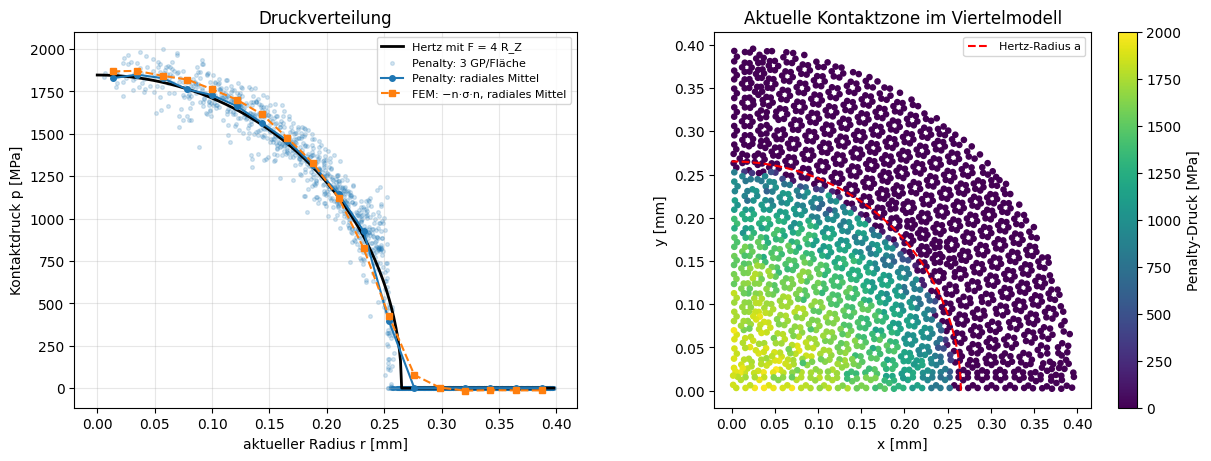

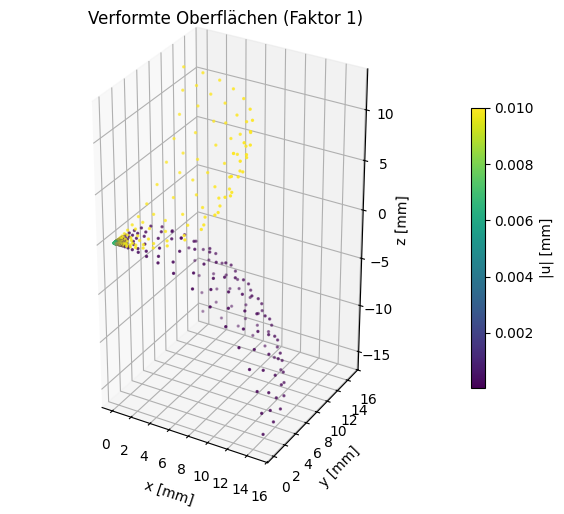

In [10]:
plot_radius = 1.5 * max(a, a_fem_area)
edges = np.linspace(0, plot_radius, 19)
radial_r, radial_p, radial_sigma = [], [], []
for left, right in zip(edges[:-1], edges[1:]):
    mask = (r_gp >= left) & (r_gp < right)
    if np.any(mask):
        radial_r.append(np.average(r_gp[mask], weights=area_weights[mask]))
        radial_p.append(np.average(p_gp[mask], weights=area_weights[mask]))
        radial_sigma.append(np.average(p_sigma[mask], weights=area_weights[mask]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
radius = np.linspace(0, plot_radius, 400)
mask = r_gp <= plot_radius
axes[0].plot(radius, hertz_pressure(radius), "k-", lw=2, label="Hertz mit F = 4 R_Z")
axes[0].scatter(r_gp[mask], p_gp[mask], s=7, alpha=.18, color="tab:blue", label="Penalty: 3 GP/Fläche")
axes[0].plot(radial_r, radial_p, "o-", ms=4, color="tab:blue", label="Penalty: radiales Mittel")
axes[0].plot(radial_r, radial_sigma, "s--", ms=4, color="tab:orange", label="FEM: −n·σ·n, radiales Mittel")
axes[0].set(xlabel="aktueller Radius r [mm]", ylabel="Kontaktdruck p [MPa]", title="Druckverteilung")
axes[0].grid(alpha=.3)
axes[0].legend(fontsize=8)
points = axes[1].scatter(contact_data[mask, 0], contact_data[mask, 1], c=p_gp[mask], s=14, cmap="viridis")
angle = np.linspace(0, np.pi/2, 200)
axes[1].plot(a * np.cos(angle), a * np.sin(angle), "r--", label="Hertz-Radius a")
axes[1].set(xlabel="x [mm]", ylabel="y [mm]", title="Aktuelle Kontaktzone im Viertelmodell", aspect="equal")
axes[1].legend(fontsize=8)
fig.colorbar(points, ax=axes[1], label="Penalty-Druck [MPa]")
fig.savefig(results / "hertz_comparison.png", dpi=180)
plt.show()

# Verschiebungsdarstellung ohne zusätzliche Rendering-Abhängigkeiten.
fig = plt.figure(figsize=(7, 5), constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")
boundary_blocks = np.unique(np.r_[slave_nodes.ravel(), master_nodes.ravel()])
coordinates = x_current[boundary_blocks]
norm_u = np.linalg.norm(uh.x.array.reshape(-1, 3)[boundary_blocks], axis=1)
sc = ax.scatter(*coordinates.T, c=norm_u, s=2, cmap="viridis")
ax.set(xlabel="x [mm]", ylabel="y [mm]", zlabel="z [mm]", title="Verformte Oberflächen (Faktor 1)")
ax.set_box_aspect(np.ptp(coordinates, axis=0))
fig.colorbar(sc, ax=ax, label="|u| [mm]", shrink=.65)
fig.savefig(results / "deformation.png", dpi=150)
plt.show()

Die Druckstreuung ist bei ebenen T4-Randflächen und nur drei Kontakt-Gaußpunkten
sichtbar. `size_min` steuert die Auflösung der Kontaktzone, `penalty_factor`
den Kompromiss zwischen Durchdringung und Konditionierung. Der Penalty-Druck
und die aus konstanten T4-Spannungen rekonstruierte Randspannung stimmen auf
einem endlichen Netz nicht exakt überein. Die Flächenvariationen tragen zu
den lokalen Kontaktkräften bei, ihre Summe verschwindet unter einer starren
Translation. Daher wird zusätzlich die Bilanz $4\int p_N n_z\,da=F$ geprüft;
das Integral des skalaren Drucks allein berücksichtigt die Flächenneigung nicht.

Für den hier kleinen Wert von `U` ist der Hertz-Vergleich sinnvoll. Bei größerem
`U` prüft das Notebook weiterhin die vollständige endliche Kinematik und die
Tangente; eine Übereinstimmung mit Hertz ist dann kein allgemeines Gütekriterium.
Die Ergebnisse (Verschiebung als XDMF/HDF5, Gaußpunktdaten, Newton-Verlauf,
Kennzahlen und Abbildungen) stehen in `results_contact_hertz_3d`.